# $\alpha,\!\beta$-CROWN Tutorial for Control Problems

This tutorial is a step-by-step introduction to four control-oriented workflows:

1. **Bound Computation**: compute certified output bounds for a reachable set.
2. **Verification**: prove a property over a continuous state set.
3. **Optimization**: solve a control objective over an allowed input interval.
4. **Satisfiability Mode**: use the dReal-like SMT interface shipped with abcrown.

The first three sections use the native $\alpha,\!\beta$-CROWN API. The final section uses the SMT-style interface.

## Common Workflow

In $\alpha,\!\beta$-CROWN, the solver reasons over a whole input box instead of only sampled points. In the first three sections we follow the same four-step pattern:

1. Build a `torch.nn.Module` whose outputs contain the quantities we want to reason about.
2. Declare symbolic input and output variables, then build the `ABCrownSolver` instance.
3. Encode the allowed input box and the desired property or objective with `IOConstraints`.
4. Call `verify(...)`, `compute_bounds(...)`, or `minimize(...)` to solve the problem.

## Optional Colab Setup

If you run this tutorial on Google Colab, use the next code cell first. It installs `abcrown` without touching Colab's preinstalled PyTorch, which avoids the long uninstall/reinstall step. The cell only installs the lightweight Python packages used by this tutorial.

In [1]:
import subprocess
import sys
from pathlib import Path

if 'google.colab' in sys.modules:
    repo_dir = Path('/content/alpha-beta-CROWN')
    if not repo_dir.exists():
        subprocess.run(
            ['git', 'clone', '--recursive', 'https://github.com/Verified-Intelligence/alpha-beta-CROWN.git', str(repo_dir)],
            check=True,
        )

    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '--upgrade', 'pip'], check=True)
    subprocess.run(
        [
            sys.executable, '-m', 'pip', 'install', '-q', '--no-deps', '-e', str(repo_dir),
            'numpy', 'packaging', 'tqdm', 'appdirs', 'ninja', 'pyyaml', 'sortedcontainers', 'termcolor', 'graphviz', 'pandas',
            'onnx', 'onnxruntime', 'onnxsim', 'skl2onnx', 'onnxoptimizer', 'psutil', 'gurobipy',
            'onnx2pytorch @ git+https://github.com/Verified-Intelligence/onnx2pytorch.git'
        ],
        check=True,
    )

    complete_verifier_dir = repo_dir / 'complete_verifier'
    if str(complete_verifier_dir) not in sys.path:
        sys.path.insert(0, str(complete_verifier_dir))

    print('Colab setup complete. Kept the preinstalled PyTorch:', __import__('torch').__version__)
else:
    print('Not running on Colab; skipping optional setup cell.')

Not running on Colab; skipping optional setup cell.


In [2]:
from pathlib import Path

import torch
import torch.nn as nn

from abcrown import ABCrownSolver, ConfigBuilder, IOConstraints, input_vars, output_vars

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(0)
torch.set_default_dtype(torch.float32)

print(f'torch: {torch.__version__}')
print(f'device: {device}')
print(f'default dtype: {torch.get_default_dtype()}')

Adding complete_verifier to sys.path
INFO     04:04:49     [tensor_storage.py:70] Hugepage enabled for branch-and-bound domains.
torch: 2.8.0+cu128
device: cuda
default dtype: torch.float32


## 1. Bound Computation: Reachability

### Problem Setting

For a discrete-time system

$$
x^+ = f(x),
$$

reachability asks for all next states that can be produced from an initial set $\mathcal{X}$:

$$
\mathcal{X}^+ = f(\mathcal{X}) = \{f(x) : x \in \mathcal{X}\}.
$$

Because this set is usually hard to compute exactly, we ask for certified componentwise bounds $\underline{x}^+$ and $\overline{x}^+$ such that

$$
\underline{x}^+ \leq f(x) \leq \overline{x}^+, \qquad \forall x \in \mathcal{X}.
$$

In this example, the transition map is written as an affine part plus a nonlinear residual:

$$
x^+ = Ax + b + r(x),
$$

with

$$
A \in \mathbb{R}^{2 \times 2}, \qquad b \in \mathbb{R}^2,
$$

and

$$
r(x) = \begin{bmatrix}
\alpha\, w^\top \sin(Wx + d) \\
\beta\, \sin(\gamma^\top x)
\end{bmatrix},
$$

where

$$
W \in \mathbb{R}^{m \times 2},\quad d \in \mathbb{R}^{m},\quad w \in \mathbb{R}^{m},
$$

and $\alpha,\beta \in \mathbb{R}$ are scaling constants. The nominal linear dynamics are augmented by smooth trigonometric residual terms.

We then compute certified bounds on $x^+$ for every $x \in \mathcal{X}$.

<p align="center"><img src="figures/tutorial_reachability_problem.png" alt="Reachability illustration" width="50%" /></p>

### Step 1: Build the Transition Dynamics

The next code cell implements the map $x^+ = Ax + b + r(x)$ exactly as written above, with two outputs corresponding to the two coordinates of the next state.

In [3]:
class ReachabilityDynamics(nn.Module):
    def __init__(self):
        super().__init__()

        # Affine backbone for Ax + b.
        self.affine = nn.Linear(2, 2)
        # Small nonlinear residual network for r(x).
        self.curved_hidden = nn.Linear(2, 6)
        self.curved_head = nn.Linear(6, 1)
        with torch.no_grad():
            # These weights implement the affine part Ax + b.
            self.affine.weight.copy_(torch.tensor([[0.28, 0.10], [-0.12, 0.74]]))
            self.affine.bias.copy_(torch.tensor([0.16, 0.06]))

            # These layers parameterize a smooth trigonometric residual r(x).
            self.curved_hidden.weight.copy_(
                torch.tensor(
                    [[2.2, -1.8], [-1.7, 2.4], [1.6, 1.5], [-2.3, -1.2], [0.9, -2.1], [-1.3, 0.8]]
                )
            )
            self.curved_hidden.bias.copy_(torch.tensor([0.35, -0.45, 0.20, 0.55, -0.15, 0.10]))
            self.curved_head.weight.copy_(torch.tensor([[1.10, -0.95, 0.85, -0.80, 0.70, -0.60]]))
            self.curved_head.bias.zero_()

    def forward(self, x):
        # Base affine transition Ax + b.
        base = self.affine(x)

        # Trigonometric residual terms for control-style nonlinear dynamics.
        curved_hidden = torch.sin(self.curved_hidden(x))
        next_x1 = base[:, 0:1] + 1.25 * self.curved_head(curved_hidden)
        next_x2 = base[:, 1:2] + 0.06 * torch.sin(0.5 * x[:, 0:1] + 1.3 * x[:, 1:2])

        # Return x^+ = [x1^+, x2^+].
        return torch.cat((next_x1, next_x2), dim=1)

### Step 2: Declare Variables and Configure Branch-and-Bound

In this step we define symbolic input/output variables and configure solver settings.

To keep tutorial runtime predictable, we set `bab/max_iterations` to cap the number of branch-and-bound iterations.
As an alternative, you can limit wall-clock time with `bab/timeout`.

In [4]:
# Instantiate the transition model from Step 1.
reach_dynamics = ReachabilityDynamics()

# Declare symbolic input/output variables for abcrown APIs.
reach_x = input_vars(2)
reach_y = output_vars(2)

# Cap BaB iterations to avoid long solve times in this tutorial.
reach_config = ConfigBuilder.from_defaults().set('bab/max_iterations', 4)
# Optional alternative: cap wall-clock time instead, e.g. .set('bab/timeout', 2.0).

# Bind model + symbolic vars + config into one solver object.
reach_solver = ABCrownSolver(reach_dynamics, reach_x, reach_y, config=reach_config)
print('Reachability solver ready')

Reachability solver ready


### Step 3: Encode the Input Set with Constraints

Now we encode the initial-state box $\mathcal{X}$ using `IOConstraints`.

In [5]:
# Encode the initial set X over which we want certified next-state bounds.
reach_lb = torch.tensor([-1.0, -0.7])
reach_ub = torch.tensor([0.8, 0.8])

reach_constraints = IOConstraints(
    input_vars=reach_x,
    input_constraint=(reach_x >= reach_lb) & (reach_x <= reach_ub),
)

print('Encoded input box constraint for reachability.')

Encoded input box constraint for reachability.


### Step 4: Compute Certified Reachable-Set Bounds

We now compute certified componentwise bounds on the next state over the full input box.
For all $x\in\mathcal{X}$, the verifier returns $\underline{x}^+, \overline{x}^+$ such that

$$
\underline{x}^+ \le f(x) \le \overline{x}^+,\qquad \forall x\in\mathcal{X}.
$$

In [6]:
# Ask abcrown for certified lower and upper bounds on both coordinates of x^+.
reach_result = reach_solver.compute_bounds(
    constraints=reach_constraints,
    objective=[reach_y[0], reach_y[1]],
)

print(f'lower bounds: {reach_result.lower}')
print(f'upper bounds: {reach_result.upper}')

[compute_bounds] input_batch=0 objectives=2 -- running LOWER subproblem (1 parallel BaB)
Model: BoundedModule(
  (/0): BoundInput(name=/0, inputs=[], perturbed=True)
  (/1): BoundParams(name=/1, inputs=[], perturbed=False)
  (/2): BoundParams(name=/2, inputs=[], perturbed=False)
  (/3): BoundParams(name=/3, inputs=[], perturbed=False)
  (/4): BoundParams(name=/4, inputs=[], perturbed=False)
  (/5): BoundParams(name=/5, inputs=[], perturbed=False)
  (/6): BoundParams(name=/6, inputs=[], perturbed=False)
  (/7): BoundLinear(name=/7, inputs=[/0, /1, /2], perturbed=True)
  (/8): BoundLinear(name=/8, inputs=[/0, /3, /4], perturbed=True)
  (/9): BoundSin(name=/9, inputs=[/8], perturbed=True)
  (/10): BoundConstant(name=/10, value=0)
  (/11): BoundConstant(name=/11, value=1)
  (/12): BoundConstant(name=/12, value=tensor([0], device='cuda:0'))
  (/13): BoundUnsqueeze(name=/13, inputs=[/11, /12], perturbed=False)
  (/14): BoundConstant(name=/14, value=tensor([0], device='cuda:0'))
  (/15): Boun

### Remark: Affine Linear Bounds and Visualization

The same pipeline can also return affine linear bounds for a selected output coordinate.
For each selected output $f_i(x)$, the returned global planes satisfy

$$
A_i^{\mathrm{L}}x + b_i^{\mathrm{L}} \le f_i(x) \le A_i^{\mathrm{U}}x + b_i^{\mathrm{U}},\qquad \forall x\in\mathcal{X}.
$$

With input Branch-and-Bound enabled, abcrown also returns local affine bounds for each active sub-domain in `subdomains['lower']` and `subdomains['upper']`.
Each sub-domain record stores its local box $(x_L, x_U)$ together with the corresponding local affine coefficients `(A, bias)`.

Below, we first retrieve these coefficients/biases, and then visualize the global and piecewise affine bounds in a separate code cell.

In [7]:
# Retrieve affine linear bounds for one selected output (x1^+).
reach_linear_result = reach_solver.compute_bounds(
    constraints=reach_constraints,
    objective=[reach_y[0]],
    return_linear_bounds=True,
)
reach_linear_bounds = reach_linear_result.linear_bounds

# Global affine planes over the whole input domain.
global_lower_A = reach_linear_bounds['lower_A']
global_lower_b = reach_linear_bounds['lower_bias']
global_upper_A = reach_linear_bounds['upper_A']
global_upper_b = reach_linear_bounds['upper_bias']

# Piecewise affine planes on BaB sub-domains.
lower_records = reach_linear_bounds['subdomains']['lower']
upper_records = reach_linear_bounds['subdomains']['upper']

print(f'global lower plane shape: {global_lower_A.shape}')
print(f'global upper plane shape: {global_upper_A.shape}')
print(f'number of lower subdomains: {len(lower_records)}')
print(f'number of upper subdomains: {len(upper_records)}')

[compute_bounds] input_batch=0 objectives=1 -- running LOWER subproblem (1 parallel BaB)
Model: BoundedModule(
  (/0): BoundInput(name=/0, inputs=[], perturbed=True)
  (/1): BoundParams(name=/1, inputs=[], perturbed=False)
  (/2): BoundParams(name=/2, inputs=[], perturbed=False)
  (/3): BoundParams(name=/3, inputs=[], perturbed=False)
  (/4): BoundParams(name=/4, inputs=[], perturbed=False)
  (/5): BoundParams(name=/5, inputs=[], perturbed=False)
  (/6): BoundParams(name=/6, inputs=[], perturbed=False)
  (/7): BoundLinear(name=/7, inputs=[/0, /1, /2], perturbed=True)
  (/8): BoundLinear(name=/8, inputs=[/0, /3, /4], perturbed=True)
  (/9): BoundSin(name=/9, inputs=[/8], perturbed=True)
  (/10): BoundConstant(name=/10, value=0)
  (/11): BoundConstant(name=/11, value=1)
  (/12): BoundConstant(name=/12, value=tensor([0], device='cuda:0'))
  (/13): BoundUnsqueeze(name=/13, inputs=[/11, /12], perturbed=False)
  (/14): BoundConstant(name=/14, value=tensor([0], device='cuda:0'))
  (/15): Boun

Now we visualize the true output surface together with the global affine planes and piecewise affine subdomain planes returned by branch-and-bound.

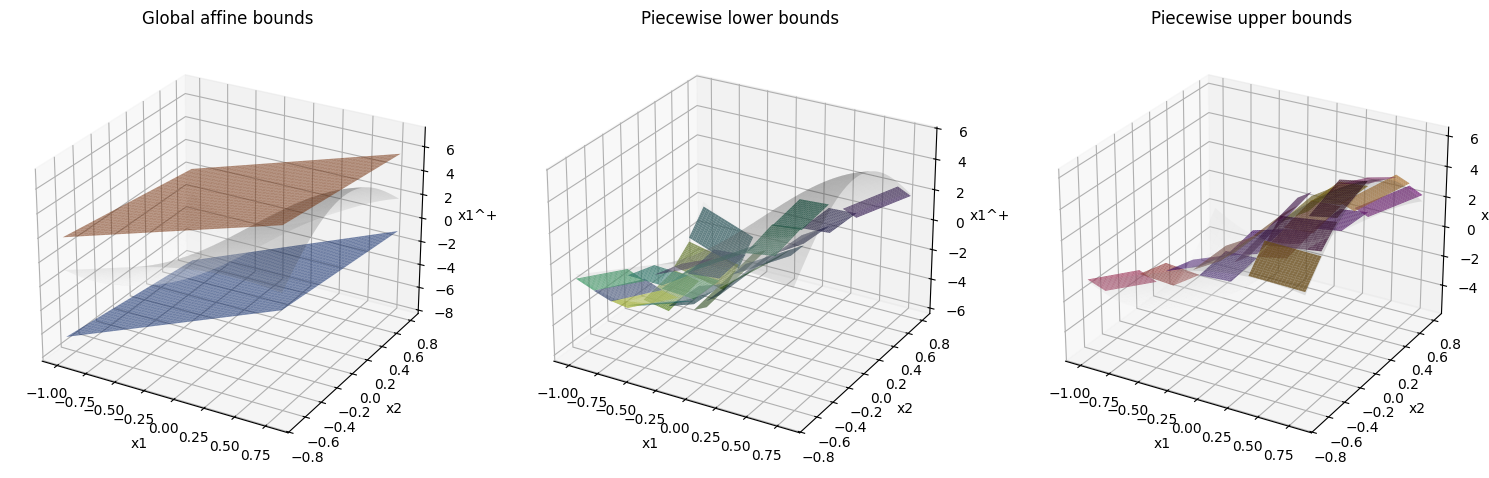

In [8]:
import matplotlib.pyplot as plt

# Visualization-specific domain/device setup.
box_lower = torch.tensor([-1.0, -0.7], dtype=global_lower_A.dtype)
box_upper = torch.tensor([0.8, 0.8], dtype=global_lower_A.dtype)
dynamics_device = next(reach_dynamics.parameters()).device

plot_x1 = torch.linspace(box_lower[0], box_upper[0], steps=81)
plot_x2 = torch.linspace(box_lower[1], box_upper[1], steps=81)
X, Y = torch.meshgrid(plot_x1, plot_x2, indexing='ij')
plot_points = torch.stack([X.reshape(-1), Y.reshape(-1)], dim=1)

surface_values = reach_dynamics(plot_points.to(dynamics_device)).detach().cpu()[:, 0].reshape(X.shape)
global_lower_surface = (plot_points @ global_lower_A.T + global_lower_b).reshape(X.shape)
global_upper_surface = (plot_points @ global_upper_A.T + global_upper_b).reshape(X.shape)

def color_sequence(name, count, start=0.15, stop=0.90):
    cmap = plt.get_cmap(name)
    if count <= 1:
        return [cmap((start + stop) / 2.0)]
    return [cmap(value) for value in torch.linspace(start, stop, steps=count).tolist()]

def plot_piecewise_planes(ax, records, colors, title):
    # Plot reference true surface in gray, then overlay local affine planes.
    ax.plot_surface(
        X.numpy(), Y.numpy(), surface_values.numpy(),
        cmap='Greys', alpha=0.16, linewidth=0, antialiased=True
    )
    for record, color in zip(records, colors):
        local_x1 = torch.linspace(record['x_L'][0], record['x_U'][0], steps=17)
        local_x2 = torch.linspace(record['x_L'][1], record['x_U'][1], steps=17)
        local_X, local_Y = torch.meshgrid(local_x1, local_x2, indexing='ij')
        local_points = torch.stack([local_X.reshape(-1), local_Y.reshape(-1)], dim=1)
        local_Z = (local_points @ record['A'].T + record['bias']).reshape(local_X.shape)
        ax.plot_surface(
            local_X.numpy(), local_Y.numpy(), local_Z.numpy(),
            color=color, alpha=0.74, linewidth=0.25, antialiased=True
        )
    ax.set_title(title)

lower_colors = color_sequence('viridis', len(lower_records), start=0.10, stop=0.92)
upper_colors = color_sequence('plasma', len(upper_records), start=0.10, stop=0.92)

# Three panels: global planes, piecewise lower planes, piecewise upper planes.
fig = plt.figure(figsize=(15.5, 4.8))
ax1 = fig.add_subplot(1, 3, 1, projection='3d')
ax2 = fig.add_subplot(1, 3, 2, projection='3d')
ax3 = fig.add_subplot(1, 3, 3, projection='3d')

ax1.plot_surface(X.numpy(), Y.numpy(), surface_values.numpy(), cmap='Greys', alpha=0.18, linewidth=0, antialiased=True)
ax1.plot_surface(X.numpy(), Y.numpy(), global_lower_surface.numpy(), color='#2563eb', alpha=0.58, linewidth=0.20, antialiased=True)
ax1.plot_surface(X.numpy(), Y.numpy(), global_upper_surface.numpy(), color='#ea580c', alpha=0.54, linewidth=0.20, antialiased=True)
ax1.set_title('Global affine bounds')

plot_piecewise_planes(ax2, lower_records, lower_colors, 'Piecewise lower bounds')
plot_piecewise_planes(ax3, upper_records, upper_colors, 'Piecewise upper bounds')

for ax in [ax1, ax2, ax3]:
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_zlabel('x1^+')
    ax.view_init(elev=26, azim=-60)

plt.tight_layout()
plt.show()

## 2. Application 2: Discrete-Time Lyapunov Stability

### Problem Setting

We certify a **discrete-time** closed-loop system

$$
x_{t+1} = f_d\bigl(x_t, \pi(x_t)\bigr) = g_d(x_t),
$$

using a trained controller and a trained Lyapunov function.

Our verification target is **local Lyapunov stability and forward invariance** on a box domain

$$
\mathcal{D} = \{x\in\mathbb{R}^2 : \underline{x} \le x \le \overline{x}\}.
$$

We use the Lyapunov sublevel set

$$
\Omega_\rho = \{x: V(x) \le \rho\}.
$$

The certified obligation is on $\Omega_\rho \cap \mathcal{D}$:

1. **Lyapunov decrease**: for each $x\in\Omega_\rho \cap \mathcal{D}$, the one-step decrease margin
$$
m(x) := (1-\kappa)V(x) - V(g(x))
$$
must satisfy $m(x) > -\varepsilon$.

2. **Forward invariance of the next state**: for each $x\in\Omega_\rho \cap \mathcal{D}$, the next state must stay in the box
$$
g_d(x) \in \mathcal{D}.
$$

So the target implication is that for any $x \in \mathcal{D}$

$$
V(x) \le \rho \;\Longrightarrow\; \Bigl(m(x) > -\varepsilon \;\land\; g_d(x) \in \mathcal{D}).
$$

For verification tools, we convert the implication to a disjunction:

$$
V(x) > \rho \;\lor\; \Bigl(m(x) > -\varepsilon \;\land\; g_d(x) \in \mathcal{D}).
$$

<p align="center"><img src="figures/tutorial_lyapunov_problem.png" alt="Lyapunov stability illustration" width="50%" /></p>

### Step 1: Build the Lyapunov Verification Setup

#### 1A) Define controlled discrete dynamics

Let $x_t=(\theta_t,\dot\theta_t)$ and $u_t=\pi(x_t)$. The discrete-time pendulum dynamics used in this tutorial are

$$
\ddot\theta_t = -\frac{\beta}{m l^2}\dot\theta_t + \frac{g}{l}\sin(\theta_t) + \frac{1}{m l^2}u_t,
$$

$$
\theta_{t+1} = \theta_t + \Delta t\,\dot\theta_t,\qquad
\dot\theta_{t+1} = \dot\theta_t + \Delta t\,\ddot\theta_t.
$$

Equivalently, $x_{t+1}=f(x_t,u_t)$ with $u_t$ provided by the controller.

In [9]:
class DiscretePendulumDynamics(nn.Module):
    def __init__(self, m=0.15, l=0.5, beta=0.1, g=9.81, dt=0.05):
        super().__init__()
        self.m = m
        self.l = l
        self.beta = beta
        self.g = g
        self.dt = dt

    def forward(self, x, u):
        # x = [theta, theta_dot], u = torque.
        theta = x[:, 0:1]
        theta_dot = x[:, 1:2]
        ml2 = self.m * self.l * self.l

        theta_ddot = (
            (-self.beta / ml2) * theta_dot
            + (self.g / self.l) * torch.sin(theta)
            + u / ml2
        )

        theta_next = theta + self.dt * theta_dot
        theta_dot_next = theta_dot + self.dt * theta_ddot
        return torch.cat((theta_next, theta_dot_next), dim=1)

    @property
    def x_equilibrium(self):
        return torch.zeros(2)

    @property
    def u_equilibrium(self):
        return torch.zeros(1)

#### 1B) Define controller and Lyapunov candidate

We define the controller and quadratic Lyapunov candidate used by the closed-loop condition:

- Controller: 4-layer MLP with clamped output torque.
- Lyapunov: $V(x)=(x-x^*)^\top (\epsilon I + R^\top R)(x-x^*)$.

These modules are later populated from the checkpoint before verification.

In [10]:
class ClampMLPController(nn.Module):
    def __init__(self, in_dim=2, hidden_dim=8, u_lo=-0.75, u_up=0.75):
        super().__init__()
        self.u_lo = float(u_lo)
        self.u_up = float(u_up)

        # Keep only the equilibrium state buffer; other buffers are unnecessary here.
        self.register_buffer('x_equilibrium', torch.zeros(in_dim))

        # Fixed 4-layer MLP: 2 -> 8 -> 8 -> 8 -> 1.
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        # Center policy around equilibrium x*=0.
        raw = self.net(x) - self.net(self.x_equilibrium)

        # Apply actuator bounds u in [u_lo, u_up].
        return torch.clamp(raw, min=self.u_lo, max=self.u_up)


class QuadraticLyapunov(nn.Module):
    def __init__(self, x_dim=2, r_rows=2, eps=0.01):
        super().__init__()
        self.x_dim = x_dim
        self.eps = eps
        self.register_buffer('goal_state', torch.zeros(x_dim))
        self.R = nn.Parameter(torch.zeros(r_rows, x_dim))

    def forward(self, x):
        x0 = x - self.goal_state
        q = self.eps * torch.eye(self.x_dim, device=x.device) + self.R.transpose(0, 1) @ self.R
        return torch.sum(x0 * (x0 @ q), dim=1, keepdim=True)

#### 1C) Define the verifier-facing Lyapunov condition module

With this parametrization, positive definiteness of Lyapunov function is already guaranteed, as we can see that $V(0) = 0$ for 

$$
V(x)=(x-x^*)^\top(\epsilon I+R^\top R)(x-x^*)
$$
Moreover, with $\epsilon>0$, $(\epsilon I+R^\top R)\succ 0$ and $V(x) > 0$ otherwise. Therefore, we only need to verify the final condition in Lyapunov theorem as introduced above. Concretely, we would verify 

1. Lyapunov decrease condition. 
$$
V(x^+) - V(x) \le -\kappa V(x) + \varepsilon,
$$
equivalently `y[0]=(1-\kappa)V(x)-V(x^+) > -\varepsilon`.

2. Forward invariance on the intersection of $\mathcal{D}$ and the sublevel set. We denote $g_d(x)=(\theta^+,\dot\theta^+)$.

The verifier-facing outputs are then:

- `y[0]`: $(1-\kappa)V(x) - V(x^+)$.
- `y[1]`: $V(x)$.
- `y[2]`: $\theta^+$.
- `y[3]`: $\dot\theta^+$.

In [11]:
class DiscreteLyapunovCondition(nn.Module):
    def __init__(self, dynamics, controller, lyapunov, kappa=0.001):
        super().__init__()
        self.dynamics = dynamics
        self.controller = controller
        self.lyapunov = lyapunov
        self.kappa = kappa

    def forward(self, x):
        # 1) Evaluate the Lyapunov value at the current state x.
        v_x = self.lyapunov(x)

        # 2) Apply the policy u = pi(x), then propagate one closed-loop step x+ = f(x, u).
        u_x = self.controller(x)
        x_next = self.dynamics(x, u_x)

        # 3) Evaluate Lyapunov value at the next state.
        v_next = self.lyapunov(x_next)

        # 4) Export verifier-facing outputs in a fixed order:
        #    y0: decrease margin, y1: current V(x), y2/y3: next-state coordinates.
        y0 = (1 - self.kappa) * v_x - v_next
        y1 = v_x
        y2 = x_next[:, 0:1]
        y3 = x_next[:, 1:2]
        return torch.cat((y0, y1, y2, y3), dim=1)

#### 1D) Instantiate modules and load checkpoint

Instantiate dynamics/controller/Lyapunov modules with matching architecture, then load the trained state dict for verification.

In [12]:
dynamics = DiscretePendulumDynamics()
controller = ClampMLPController(in_dim=2, hidden_dim=8, u_lo=-0.75, u_up=0.75)
lyapunov = QuadraticLyapunov(x_dim=2, r_rows=2, eps=0.01)

# Load pretrained parameters for the full DiscreteLyapunovCondition module.
ckpt_path = Path('neural_lyapunov_dependency') / 'pendulum_discrete_state_feedback_quadratic.pt'
ckpt = torch.load(ckpt_path, map_location=device)

lyapunov_condition = DiscreteLyapunovCondition(
    dynamics=dynamics,
    controller=controller,
    lyapunov=lyapunov,
).to(device)

# strict=False allows loading only the matched parameters after controller simplification.
lyapunov_condition.load_state_dict(ckpt['state_dict'], strict=False)

print(f'loaded checkpoint: {ckpt_path}')
print('Lyapunov condition weights loaded.')

loaded checkpoint: neural_lyapunov_dependency/pendulum_discrete_state_feedback_quadratic.pt
Lyapunov condition weights loaded.


### Step 2: Declare Variables and Configure the Solver

The condition module maps a 2D state to a 4D output vector used by the property encoding.

In [13]:
# abcrown uses symbolic variables to represent network I/O in constraints.
# Here: 2-D input state x -> 4-D output vector y from DiscreteLyapunovCondition.
lyap_x = input_vars(2)
lyap_y = output_vars(4)

# ConfigBuilder controls verification settings (branching, bounds, tolerances, etc.).
lyap_cfg = ConfigBuilder.from_defaults()

# ABCrownSolver binds together:
#   (a) the PyTorch module to verify,
#   (b) symbolic input/output variables,
#   (c) verifier configuration.
# After this, we can call verify(...) on any IOConstraints over (lyap_x, lyap_y).
lyap_solver = ABCrownSolver(lyapunov_condition, lyap_x, lyap_y, config=lyap_cfg)

print('Lyapunov solver ready')

Lyapunov solver ready


### Step 3: Encode the Property

We now encode the input box and output logic.

The input box is

$$
\underline{\theta} \le \theta \le \overline{\theta},\qquad \underline{\dot\theta} \le \dot\theta \le \overline{\dot\theta}.
$$

The output logic (safe form) is

$$
V(x) > \rho\;\lor\;\Bigl((1-\kappa)V(x) - V(x^+) > -\varepsilon\;\land\;-b < \theta^+ < b\;\land\;-b < \dot\theta^+ < b\Bigr).
$$

Here $\rho$ is the Lyapunov sublevel threshold, $\varepsilon$ is the decrease tolerance, and $b$ is the forward-invariance bound on the next pendulum state. The exact values are assigned in the code cell below.

In [14]:
# Property constants used in the verifier formula.
rho_level = 75.2487
decrease_tol = 1e-6

# Verification domain (input box) for x = [theta, theta_dot].
x0_lo = -12.0
x0_hi = 12.0
x1_lo = -12.0
x1_hi = 12.0

# IOConstraints is the bridge from math property -> verifier input.
# input_constraint: set of states where the property must hold.
# output_constraint: logical formula over y = model(x), where
#   y0=(1-kappa)V(x)-V(x+), y1=V(x), y2=theta+, y3=theta_dot+.
lyap_constraints = IOConstraints(
    input_vars=lyap_x,
    output_vars=lyap_y,
    input_constraint=((lyap_x[0] >= x0_lo) & (lyap_x[0] <= x0_hi) & (lyap_x[1] >= x1_lo) & (lyap_x[1] <= x1_hi)),

    # Encode implication as disjunction:
    #   V(x) <= rho  =>  [decrease + next-state invariance]
    # equivalent to
    #   V(x) > rho OR [decrease + next-state invariance].
    output_constraint=(lyap_y[1] > rho_level) | (
        (lyap_y[0] > -decrease_tol)
        & (lyap_y[2] > x0_lo)
        & (lyap_y[2] < x0_hi)
        & (lyap_y[3] > x1_lo)
        & (lyap_y[3] < x1_hi)
    ),
)

print('Encoded Lyapunov + forward-invariance property.')
print(f'Input box: x0 in [{x0_lo}, {x0_hi}], x1 in [{x1_lo}, {x1_hi}]')
print('Property: y1 > rho OR (y0 > -1e-6 and next state within +/-12.0).')

Specification DNF: (y[1] > 75.2487) | ((y[0] > -1e-06) & (y[2] > -12) & (y[2] < 12) & (y[3] > -12) & (y[3] < 12))
Encoded Lyapunov + forward-invariance property.
Input box: x0 in [-12.0, 12.0], x1 in [-12.0, 12.0]
Property: y1 > rho OR (y0 > -1e-6 and next state within +/-12.0).


### Step 4: Run Verification and Inspect the Result

This call asks abcrown to prove the local Lyapunov condition over the full state box, then prints the returned status and stats.

Possible return statuses are:
- `verified`: the property is proved over the whole input set.
- `falsified`: a counterexample is found.
- `unknown`: neither proof nor counterexample is obtained under the current settings.

If the status is `falsified`, inspect:
- `lyap_result.stats['attack_examples']` (counterexample inputs).

In [15]:
# Run complete verification on the encoded property.
# Internally, abcrown computes certified bounds over the input set and tries to
# prove the formula for all x in the box (or return counterexample/unknown).
lyap_result = lyap_solver.verify(constraints=lyap_constraints)

# Main verdict: verified / falsified / unknown.
print(f'status: {lyap_result.status}')

# If status is falsified, inspect counterexample inputs at:
#   lyap_result.stats['attack_examples']

Attack parameters: initialization=uniform, steps=100, restarts=30, alpha=3.0, GAMA=False
PGD attack margin (first 2 examples and 10 specs):
 tensor([[9855.16113281, 9855.16113281, 9855.16113281, 9855.16113281,
         9855.16113281]], device='cuda:0')
Total number of violation:  0
Processing batch 1/1...


100%|██████████| 100/100 [00:00<00:00, 217.60it/s]
/home/haoyuli5/tutorial/alpha-beta-CROWN/complete_verifier/auto_LiRPA/operators/leaf.py:93: UserWarning: The "has_batchdim" option for BoundBuffers is deprecated. It may be removed from the next release.
  warnings.warn('The "has_batchdim" option for BoundBuffers is deprecated.'


PGD attack margin (first 2 examples and 10 specs):
 tensor([[9.26887058e-03, 9.26697159e+00, 9.69599152e+00, 3.38066101e-01,
         4.82258797e-01]], device='cuda:0')
Total number of violation:  0
Attack finished in 0.4850 seconds.
PGD attack failed
verified_status unknown
verified_success False
Model: BoundedModule(
  (/0): BoundInput(name=/0, inputs=[], perturbed=True)
  (/1): BoundBuffers(name=/1, inputs=[], perturbed=False)
  (/2): BoundParams(name=/2, inputs=[], perturbed=False)
  (/3): BoundParams(name=/3, inputs=[], perturbed=False)
  (/4): BoundParams(name=/4, inputs=[], perturbed=False)
  (/5): BoundParams(name=/5, inputs=[], perturbed=False)
  (/6): BoundParams(name=/6, inputs=[], perturbed=False)
  (/7): BoundParams(name=/7, inputs=[], perturbed=False)
  (/8): BoundParams(name=/8, inputs=[], perturbed=False)
  (/9): BoundParams(name=/9, inputs=[], perturbed=False)
  (/10): BoundParams(name=/10, inputs=[], perturbed=False)
  (/11): BoundBuffers(name=/11, inputs=[], perturbe

100%|██████████| 5/5 [00:00<00:00, 228.79it/s]

PGD attack margin (first 2 examples and 10 specs):
 tensor([[1.72156051e-01, 3.18377991e+01, 1.21705139e+02, 3.18377991e+01,
         7.86812561e+02, 1.47651644e+01]], device='cuda:0')
Total number of violation:  0
Current pickout batch: 5


...

PGD attack margin (first 2 examples and 10 specs):
 tensor([[9.99999997e-07, 1.38328676e-06, 2.11810357e-06, 2.53302187e-06,
         1.38328676e-06]], device='cuda:0')
Total number of violation:  0
Current pickout batch: 4


Worst bound: tensor([-7.52487030e+01, -3.41803002e-07], device='cuda:0')
Time: adv_check 0.0263    pickout 0.0003    split 0.0008    init 0.0002    concretize 0.0002    bounding 0.0766    filtering 0.0002    decision 0.0002    add_domain 0.0003    summary 0.0002    
Accumulated time: adv_check 1.0086    pickout 0.0120    split 0.0295    bounding 3.1506    init 0.0959    concretize 0.0961    filtering 0.0092    decision 0.0067    add_domain 0.0135    summary 0.0082    
Length of domains: 2
20255 domains visited
Current (lb-rhs): tensor([[-7.52487030e+01, -3.41803002e-07]], device='cuda:0')
Cumulative time: 4.281356334686279

Iteration 39


100%|██████████| 5/5 [00:00<00:00, 231.69it/s]

PGD attack margin (first 2 examples and 10 specs):
 tensor([[9.99999997e-07, 1.27955241e-06, 1.27955241e-06]], device='cuda:0')
Total number of violation:  0
Current pickout batch: 2


Worst bound: tensor([-7.52487030e+01,  2.85908413e-07], device='cuda:0')
No domains left, verification finished!
Time: adv_check 0.0263    pickout 0.0003    split 0.0007    init 0.0002    concretize 0.0002    bounding 0.0765    filtering 0.0002    decision 0.0002    add_domain 0.0003    summary 0.0000    
Accumulated time: adv_check 1.0349    pickout 0.0123    split 0.0302    bounding 3.2272    init 0.0980    concretize 0.0983    filtering 0.0094    decision 0.0067    add_domain 0.0135    summary 0.0082    
Length of domains: 0
20259 domains visited
Cumulative time: 4.385747194290161

status: verified


### Remark: Continuous-Time Lyapunov Verification and Jacobian Operators

The same API also supports continuous-time Lyapunov stability verification.

For example, with tolerance $\varepsilon>0$ we can verify

$$
V(x) \le \rho \implies \dot V(x) < \varepsilon,
$$

which is equivalent to the disjunction

$$
V(x) > \rho \;\lor\; \dot V(x) < \varepsilon.
$$

This can be encoded with Jacobian operators (for example, Jacobian-vector products used in $\dot V(x)=\nabla V(x)\,f(x)$ reasoning), which is useful for certifying continuous dynamics and controller-Lyapunov conditions in a unified workflow.


In [16]:
# Example sketch: continuous-time Lyapunov verification with JacobianOP, matching the earlier pattern.
from auto_LiRPA.jacobian import JacobianOP

class ContinuousTimeLyapunovCondition(nn.Module):
    def __init__(self, f_net, v_net):
        super().__init__()
        self.f_net = f_net  # Continuous dynamics: x_dot = f(x).
        self.v_net = v_net  # Lyapunov candidate: V(x).

    def forward(self, x):
        # Match previous style: represent dV/dx in the graph via JacobianOP.
        x = x.clone().requires_grad_(True)
        V = self.v_net(x)
        x_dot = self.f_net(x)
        dVdx = JacobianOP.apply(self.v_net(x), x).squeeze(1)
        V_dot = torch.sum(dVdx * x_dot, dim=1, keepdim=True)
        return torch.cat((V, V_dot), dim=1)  # y[0]=V(x), y[1]=V_dot(x).


ct_f = nn.Sequential(nn.Linear(2, 16), nn.Tanh(), nn.Linear(16, 2))
ct_v = nn.Sequential(nn.Linear(2, 16), nn.Tanh(), nn.Linear(16, 1))
ct_condition = ContinuousTimeLyapunovCondition(ct_f, ct_v).eval()

# Tolerance form: V(x) > rho OR V_dot(x) < +eps.
ct_x = input_vars(2)
ct_y = output_vars(2)
ct_eps = 1e-6
ct_rho = 0.2
ct_solver = ABCrownSolver(ct_condition, ct_x, ct_y, config=ConfigBuilder.from_defaults())

ct_constraints = IOConstraints(
    input_vars=ct_x,
    output_vars=ct_y,
    input_constraint=((ct_x >= [-0.5, -0.5]) & (ct_x <= [0.5, 0.5])),
    output_constraint=(ct_y[0] > ct_rho) | (ct_y[1] < ct_eps),
)

print('Continuous-time JacobianOP example is set up.')
print('Outputs: y[0]=V(x), y[1]=V_dot(x)=∇V(x)·f(x).')


Specification DNF: (y[0] > 0.2) | (y[1] < 1e-06)
Continuous-time JacobianOP example is set up.
Outputs: y[0]=V(x), y[1]=V_dot(x)=∇V(x)·f(x).


## 3. Optimization Example
### Problem Setting
We use a 1D point-mass model with state $s_t=[p_t, v_t]^\top$, where $p_t$ is position and $v_t$ is velocity.
The control is acceleration $u_t$. We keep a short horizon $N=4$, so the optimizer chooses $u_0,u_1,u_2,u_3$.
Control limits are boxed:
$$
u_t \in [\underline u_t, \overline u_t],\qquad t=0,1,2,3.
$$
We use a mildly nonlinear damped point-mass model:
$$
p_{t+1}=p_t+\Delta t\,v_t,
$$
$$
v_{t+1}
=
v_t+\Delta t\left(u_t-c_v v_t-k\sin(p_t)\right),
$$
with $c_v, k$ being predefined constants.
Starting from fixed $(p_0,v_0)$ and targeting $(p^\star,v^\star)$, we minimize
$$
\min_{u\in\mathcal U} J(u),\qquad
J(u)=J_p+0.35J_v+0.08J_u,
$$
with terminal-tracking and effort terms
$$
J_p=(p_4-p^\star)^2,\qquad
J_v=(v_4-v^\star)^2,\qquad
J_u=\sum_{t=0}^{3}|u_t|.
$$

### Step 1: Define the MPC Dynamics Module

The next code cell defines a short-horizon point-mass MPC rollout. It maps the 4-step control sequence to three scalar cost components $[J_p, J_v, J_u]^\top$.


In [17]:
class SimpleMPCDynamics(nn.Module):
    def __init__(self, horizon=4, dt=0.30, damping=0.24, nonlinear_strength=0.20):
        super().__init__()
        self.horizon = horizon
        self.dt = dt
        self.damping = damping
        self.nonlinear_strength = nonlinear_strength

        # Fixed initial/target states.
        self.p0 = -1.2
        self.v0 = 0.9
        self.p_target = 1.0
        self.v_target = 0.0

    def forward(self, u_seq):
        u_seq = u_seq.to(dtype=torch.float32)
        batch = u_seq.shape[0]

        p = torch.full((batch, 1), self.p0, dtype=u_seq.dtype, device=u_seq.device)
        v = torch.full((batch, 1), self.v0, dtype=u_seq.dtype, device=u_seq.device)

        effort_cost = torch.zeros_like(p)

        for t in range(self.horizon):
            u_t = u_seq[:, t:t+1]

            # Roll out one step of mildly nonlinear point-mass dynamics.
            # The term -k sin(p) can be viewed as a position-dependent force.
            p = p + self.dt * v
            v = v + self.dt * (
                u_t
                - self.damping * v
                - self.nonlinear_strength * torch.sin(p)
            )

            effort_cost = effort_cost + torch.abs(u_t)

        pos_error = p - self.p_target
        vel_error = v - self.v_target

        pos_cost = pos_error * pos_error
        vel_cost = vel_error * vel_error

        return torch.cat((pos_cost, vel_cost, effort_cost), dim=1)

### Step 2: Instantiate the Solver

The following code cell instantiates the MPC rollout model, declares the 4 control variables, sets the timeout guard, and binds everything into an `ABCrownSolver`.

In [18]:
# Instantiate the short-horizon point-mass MPC dynamics.
cost_dynamics = SimpleMPCDynamics(
    horizon=4,
    dt=0.30,
    damping=0.24,
    nonlinear_strength=0.50,
)
# Declare control sequence u0,u1,u2,u3 and output costs [Jp, Jv, Ju].
cost_x = input_vars(4)
cost_y = output_vars(3)
cost_config = ConfigBuilder.from_defaults()
cost_solver = ABCrownSolver(cost_dynamics, cost_x, cost_y, config=cost_config)
print('Optimization solver ready')

Optimization solver ready


### Step 3: Define Constraints and Objective

The next code cell adds the boxed control constraints and the scalar objective
$$
J(u)=J_p+0.35J_v+0.08J_u.
$$

In [19]:
# Encode box constraints for each control input in the sequence.
cost_constraints = IOConstraints(
    input_vars=cost_x,
    input_constraint=(
        (cost_x >= [-1.2, -1.2, -1.2, -1.2])
        & (cost_x <= [1.2, 1.2, 1.2, 1.2])
    ),
)

# Build scalar objective J(u) = Jp + 0.35 Jv + 0.08 Ju.
cost_objective = cost_y[0] + 0.35 * cost_y[1] + 0.08 * cost_y[2]
print('Constraints and objective ready')

Constraints and objective ready


### Step 4: Solve the Optimization Problem

We now solve the boxed optimization over the 4-step control sequence. We request `return_bound_history=True` so the solver also returns the primal and dual sequences.

In [20]:
# Solve the optimization problem
cost_result = cost_solver.minimize(
    objective=cost_objective,
    constraints=cost_constraints,
    return_bound_history=True,
)

# Print the best objective value and the associated control input
print("\n=== Optimization Result Summary ===")
print(f"primal_value: {cost_result.primal_value}")
print(f"x_best: {cost_result.x_best}")

/home/haoyuli5/tutorial/alpha-beta-CROWN/complete_verifier/api.py:1629: TracerWarning: Converting a tensor to a Python integer might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if base_output.shape[1] != int(self.objective_row.numel()):
/home/haoyuli5/tutorial/alpha-beta-CROWN/complete_verifier/api.py:1629: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if base_output.shape[1] != int(self.objective_row.numel()):


Model: BoundedModule(
  (/0): BoundInput(name=/0, inputs=[], perturbed=True)
  (/1): BoundBuffers(name=/1, inputs=[], perturbed=False)
  (/2): BoundCast(name=/2, inputs=[/0], perturbed=True)
  (/3): BoundConstant(name=/3, value=0)
  (/4): BoundShape(name=/4, inputs=[/2], perturbed=False)
  (/5): BoundConstant(name=/5, value=0)
  (/6): BoundGather(name=/6, inputs=[/4, /5], perturbed=False)
  (/7): BoundConstant(name=/7, value=1)
  (/8): BoundConstant(name=/8, value=tensor([0], device='cuda:0'))
  (/9): BoundUnsqueeze(name=/9, inputs=[/6, /8], perturbed=False)
  (/10): BoundConstant(name=/10, value=tensor([0], device='cuda:0'))
  (/11): BoundUnsqueeze(name=/11, inputs=[/7, /10], perturbed=False)
  (/12): BoundConcat(name=/12, inputs=[/9, /11], perturbed=False)
  (/13): BoundConstant(name=/13, value=tensor([0], device='cuda:0'))
  (/14): BoundUnsqueeze(name=/14, inputs=[/6, /13], perturbed=False)
  (/15): BoundConstant(name=/15, value=tensor([0], device='cuda:0'))
  (/16): BoundUnsqueeze(

 40%|████      | 2/5 [00:00<00:00, 151.39it/s]

pgd early stop
PGD attack margin (first 2 examples and 10 specs):
 tensor([[-0.03485405]], device='cuda:0')
Total number of violation:  1
Trying to update RHS with attack
  Current RHS: mean 1.0137369632720947
  New upper bound: mean 0.978882908821106
  Number of updated RHS: 1/1
  Gap between lower/upper bounds: mean 0.7614688873291016, min 0.7614688873291016
Worst bound: tensor([-0.43361127], device='cuda:0')
Time: sort_domains 0.0002    pickout 0.0004    update_rhs_with_attack 0.0299    split 0.0015    init 0.0002    concretize 0.0002    bounding 0.1469    filtering 0.0001    decision 0.0001    add_domain 0.0003    summary 0.0002    
Accumulated time: sort_domains 0.0002    pickout 0.0004    update_rhs_with_attack 0.0299    split 0.0015    bounding 0.1469    init 0.0035    concretize 0.0035    filtering 0.0001    decision 0.0001    add_domain 0.0003    summary 0.0002    
Length of domains: 4
5 domains visited
Current (lb-rhs): tensor([[-0.43361127]], device='cuda:0')


Cumulative time: 0.20445466041564941

Iteration 2
Current pickout batch: 4
Running PGD attack on 4 domains


...

pgd early stop
PGD attack margin (first 2 examples and 10 specs):
 tensor([[5.96046448e-07, 1.78813934e-06, 0.00000000e+00, 0.00000000e+00,
         2.98023224e-07, 2.98023224e-07, 0.00000000e+00, 0.00000000e+00,
         0.00000000e+00, 5.96046448e-07]], device='cuda:0')
Total number of violation:  0
Trying to update RHS with attack
  Current RHS: mean 0.9666017889976501
  New upper bound: mean 0.9666021466255188
  Number of updated RHS: 0/10
  Gap between lower/upper bounds: mean 1.1503697123771417e-06, min 1.7881393432617188e-07


Worst bound: tensor([-1.60932541e-06], device='cuda:0')
Time: sort_domains 0.0002    pickout 0.0003    update_rhs_with_attack 0.0126    split 0.0008    init 0.0002    concretize 0.0002    bounding 0.1461    filtering 0.0002    decision 0.0001    add_domain 0.0003    summary 0.0002    
Accumulated time: sort_domains 0.0073    pickout 0.0114    update_rhs_with_attack 0.5074    split 0.0296    bounding 5.5745    init 0.1310    concretize 0.1313    filtering 0.0082    decision 0.0024    add_domain 0.0129    summary 0.0081    
Length of domains: 12
859 domains visited
Current (lb-rhs): tensor([[-1.60932541e-06]], device='cuda:0')
Cumulative time: 6.231963396072388

Iteration 39
Current pickout batch: 12
Running PGD attack on 10 domains


 20%|██        | 1/5 [00:00<00:00, 121.37it/s]

pgd early stop
PGD attack margin (first 2 examples and 10 specs):
 tensor([[5.96046448e-07, 0.00000000e+00, 2.98023224e-07, 0.00000000e+00,
         5.96046448e-07, 2.98023224e-07, 0.00000000e+00, 0.00000000e+00,
         0.00000000e+00, 0.00000000e+00]], device='cuda:0')
Total number of violation:  0
Trying to update RHS with attack
  Current RHS: mean 0.9666017889976501
  New upper bound: mean 0.9666019678115845
  Number of updated RHS: 0/10
  Gap between lower/upper bounds: mean 8.404255140703754e-07, min 0.0


Worst bound: tensor([-8.34465027e-07], device='cuda:0')
Time: sort_domains 0.0002    pickout 0.0003    update_rhs_with_attack 0.0126    split 0.0008    init 0.0002    concretize 0.0002    bounding 0.1461    filtering 0.0002    decision 0.0001    add_domain 0.0003    summary 0.0002    
Accumulated time: sort_domains 0.0075    pickout 0.0117    update_rhs_with_attack 0.5200    split 0.0303    bounding 5.7206    init 0.1345    concretize 0.1348    filtering 0.0084    decision 0.0025    add_domain 0.0132    summary 0.0083    
Length of domains: 13
883 domains visited
Current (lb-rhs): tensor([[-8.34465027e-07]], device='cuda:0')
Optimization early stop: lower bound reached current threshold within tolerance (gap=-8.344650268554688e-07, tol=1e-06).

=== Optimization Result Summary ===
primal_value: 0.9665071964263916
x_best: tensor([ 1.20000005,  0.74062502,  0.00000000, -1.20000005])


### Step 5: Plot the Returned Convergence History

The solver history records how the best primal value and the certified dual bound evolve across input branch-and-bound iterations.

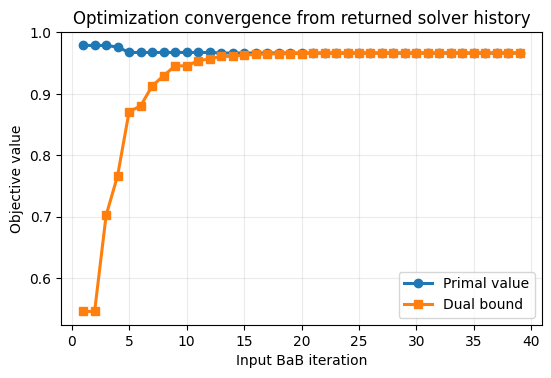

In [21]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# Read the primal and dual sequences returned by minimize(...).
history = cost_result.bound_history
if history is not None and history['primal_values']:
    iterations = range(1, len(history['primal_values']) + 1)
    fig, ax = plt.subplots(figsize=(6.2, 3.8))
    # Plot the best feasible objective found so far.
    ax.plot(iterations, history['primal_values'], marker='o', markersize=6, linewidth=2.2, label='Primal value')
    # Plot the certified lower bound maintained during branch-and-bound.
    ax.plot(iterations, history['dual_bounds'], marker='s', markersize=6, linewidth=2.2, label='Dual bound')
    ax.set_xlabel('Input BaB iteration')
    ax.set_ylabel('Objective value')
    ax.set_title('Optimization convergence from returned solver history')
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(alpha=0.25)
    ax.legend()
    plt.show()
else:
    print('No bound history was returned.')

## 4. SMT Mode: dReal-Compatible API

The SMT interface works directly with logical formulas and is designed to be compatible with existing dReal-style SMT workflows for nonlinear real arithmetic. In this example, we ask whether the surface $z = \sin(x) + \cos(y)$ intersects a bounded 3D box.

Formally, we check satisfiability of the conjunction

$$
\varphi \;:=\; (0 \le x) \;\land\; (x \le 2\pi) \;\land\; (0 \le y) \;\land\; (y \le 2\pi) \;\land\; (-2 \le z) \;\land\; (z \le 2) \;\land\; (\sin(x)+\cos(y)=z).
$$

Equivalently, this is the SMT problem

$$
\exists x,y,z \in \mathbb{R}\;:\; \varphi,
$$

with all variable bounds and the nonlinear equality written explicitly in the clauses above.

<p align="center"><img src="figures/tutorial_sat_problem.png" alt="Satisfiability illustration" width="50%" /></p>

We use the box $x \in [0, 2\pi]$, $y \in [0, 2\pi]$, $z \in [-2, 2]$. The code below uses the SMT interface in `abcrown`.

In [22]:
from abcrown.abcrown_smt import *

two_pi = 6.283185307179586
x = Variable('x')
y = Variable('y')
z = Variable('z')

formula = And(
    0 <= x, x <= two_pi,
    0 <= y, y <= two_pi,
    -2 <= z, z <= 2,
    sin(x) + cos(y) == z,
)

sat_result = CheckSatisfiability(formula, 0.001)
print(sat_result)

SAT
x=1.564485; y=0.000000; z=2.000000
[sanity:PASS] math=1.99144e-05 torch=1.99144e-05 tol=0.001


## Summary

The four workflows use the same formulation pattern but answer different control questions:

- `verify(...)` proves a property over a continuous state set,
- `compute_bounds(...)` returns certified reachable-set bounds,
- `minimize(...)` solves for the best control input under box constraints,
- `CheckSatisfiability(...)` asks whether a nonlinear formula has a witness.

Once the problem is written as a system description or a logical formula, $\alpha,\!\beta$-CROWN can reason about the whole set rather than isolated samples.